# Predict the pedestal using ESCAPE for SPARC baseline scenario

In [1]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
from scipy.interpolate import interp1d
import tempfile
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

from examples.device_prediction.helper_functions import read_sparcpublic_profiles, psi_n_and_rho_psi, build_manual_profs, calc_pressure_profile, _print_profile_summary, read_popcon, _to_watts

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [2]:
# Import the SPARC baseline scenario geqdsk (freely available from SPARCPublic)
import urllib.parse

_SPARC_PRD = 'https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/PrimaryReferenceDischarge'
_SPARC_GEQDSK = '2 - SPARC_DN_PRD_freegs_20221013'


def fetch_text(filename):
    """Read a file from the SPARCPublic PRD folder over HTTP."""
    url = f'{_SPARC_PRD}/{urllib.parse.quote(filename)}'
    print(f'Fetching {filename} from SPARCPublic...', end=' ', flush=True)
    with urllib.request.urlopen(url) as resp:
        text = resp.read().decode()
    print('done.')
    return text


# Persist gEQDSK for mhd_load / profiles_loop_solve (needs a filepath).
# Leading 'g' keeps equil_tag = Path(mhd_fp).name[1:] sensible.
mhd_fp = 'gSPARC_DN_PRD.geqdsk'
geqdsk_text = fetch_text(_SPARC_GEQDSK)
Path(mhd_fp).write_text(geqdsk_text)
print(f'Wrote {mhd_fp}')

eqdsk = read_eqdsk(mhd_fp)

print(f"  Ip      = {eqdsk['ip']/1.E6:.2f} MA")
print(f"  F0      = {eqdsk['rcentr']*eqdsk['bcentr']:.2f} T.m  (B0 = {eqdsk['rcentr']*eqdsk['bcentr']/1.85:.2f} T at R0 = 1.85 m)")
print(f"  p_axis  = {eqdsk['pres'][0]/1.E6:.2f} MPa")
print(f"  axis    = ({eqdsk['raxis']:.3f}, {eqdsk['zaxis']:.3f}) m")


Fetching 2 - SPARC_DN_PRD_freegs_20221013 from SPARCPublic... done.
Wrote gSPARC_DN_PRD.geqdsk
  Ip      = 8.70 MA
  F0      = 22.49 T.m  (B0 = 12.16 T at R0 = 1.85 m)
  p_axis  = 2.60 MPa
  axis    = (1.890, -0.000) m


Using 6 - cgyro_20221013.txt (cgyro) for manual_profs
Loaded 6 - cgyro_20221013.txt (cgyro): 201 points
  quantities: ['rho', 'polflux', 'q', 'Te', 'Ti', 'ne']
  psi_N mapping: using polflux -> rho_psi=sqrt(psi_N) (max |rho_file^2 - psi_N| = 0.202)
  Te axis  = 23.42 keV,  edge = 0.27 keV
  ne axis  = 4.96e20 m^-3,  edge = 0.85e20 m^-3
  Ti axis  = 17.13 keV,  edge = 0.58 keV
  ni: not in file


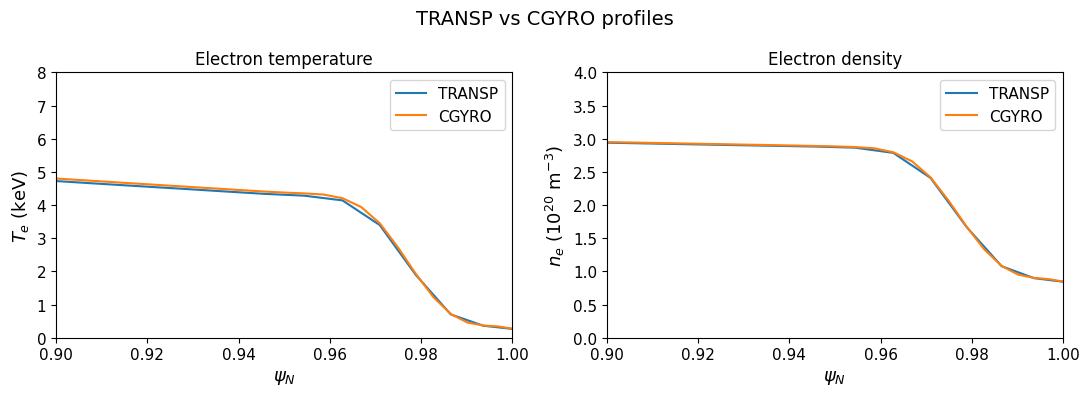

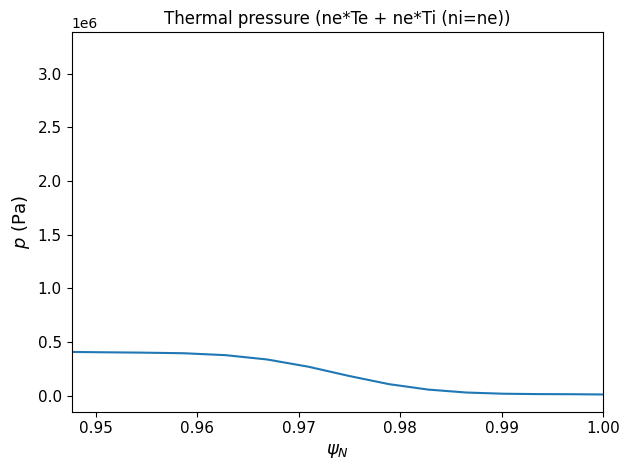

Pressure at pedestal top [MPa]:  0.40754162678157946


In [3]:
# Import SPARC kinetic profiles from local SPARCPublic exports.
# TRANSP: 5 - transp_20221013.txt
# CGYRO:  6 - cgyro_20221013.txt
# Sections: rho, polflux, q, te [keV], ti [keV], ne [10^19/m^3] (ni optional).

TRANSP_PATH = Path('5 - transp_20221013.txt')
CGYRO_PATH = Path('6 - cgyro_20221013.txt')
PROFILE_SOURCE = 'cgyro'   # 'transp' or 'cgyro' — feeds manual_profs for the solve
OVERPLOT_PROFILES = True   # if True, plot TRANSP and CGYRO together for comparison


read_transp_profiles = read_sparcpublic_profiles
read_cgyro_profiles = read_sparcpublic_profiles

profiles_transp = read_transp_profiles(TRANSP_PATH)
profiles_cgyro = read_cgyro_profiles(CGYRO_PATH)

source = PROFILE_SOURCE.strip().lower()
if source == 'transp':
    profiles = profiles_transp
    prof_path = TRANSP_PATH
elif source == 'cgyro':
    profiles = profiles_cgyro
    prof_path = CGYRO_PATH
else:
    raise ValueError(f"PROFILE_SOURCE must be 'transp' or 'cgyro', got {PROFILE_SOURCE!r}")

manual_profs = build_manual_profs(profiles)

print(f'Using {prof_path.name} ({source}) for manual_profs')
_print_profile_summary(source, prof_path, profiles)
# calc_pressure_profile returns (psi_N, p [Pa], mode) and does the
# 10^20 m^-3 -> m^-3 conversion internally.
psi_N_p, p, p_mode = calc_pressure_profile(manual_profs)

if OVERPLOT_PROFILES:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    for ax, qty, ylabel in zip(
        axes,
        ('Te', 'ne'),
        (r'$T_e$ (keV)', r'$n_e$ ($10^{20}$ m$^{-3}$)'),
    ):
        for label, prof, color in (
            ('TRANSP', profiles_transp, 'C0'),
            ('CGYRO', profiles_cgyro, 'C1'),
        ):
            psi_N, _ = psi_n_and_rho_psi(prof)
            y = prof[qty] if qty == 'Te' else prof[qty] / 1e20
            ax.plot(psi_N, y, '-', color=color, label=label)
        ax.set_xlabel(r'$\psi_N$', fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.legend(fontsize=11)
        ax.tick_params(labelsize=11)
        ax.set_xlim(0.9, 1)
    axes[0].set_ylim(0, 8)
    axes[1].set_ylim(0, 4)
    axes[0].set_title('Electron temperature')
    axes[1].set_title('Electron density')
    fig.suptitle('TRANSP vs CGYRO profiles', fontsize=14)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(psi_N_p, p)
    ax.set_xlabel(r'$\psi_N$', fontsize=13)
    ax.set_ylabel(r'$p$ (Pa)', fontsize=13)
    ax.tick_params(labelsize=11)
    ax.set_title(f'Thermal pressure ({p_mode})')
    ax.set_xlim([0.9476,1.0])
    plt.tight_layout()
    plt.show()
    ptop = interp1d(psi_N_p, p, kind='linear', bounds_error=False, fill_value='extrapolate')(0.9476)
    print('Pressure at pedestal top [MPa]: ', ptop/1e6)

In [4]:
# Import heating power and Zeff from SPARCPublic POPCON table
POPCON_PATH = Path('1 - PRD_POPCON_20221013.csv')


popcon = read_popcon(POPCON_PATH, keys=('Ohmic power', 'RF power', 'Zeff'))

P_ohmic = _to_watts(popcon['Ohmic power']['value'], popcon['Ohmic power']['unit'])  # W
P_RF = _to_watts(popcon['RF power']['value'], popcon['RF power']['unit'])            # W
Zeff = float(popcon['Zeff']['value'])  # dimensionless

# P_tot_e: heating power to electrons [W].
# Saarelma et al. take ~half of the total (Ohmic+RF) heating as electron channel.
P_tot_e = (P_ohmic + P_RF) / 2

print(f'Loaded POPCON inputs from {POPCON_PATH.name}:')
print(f'  P_ohmic = {P_ohmic/1e6:.2f} MW')
print(f'  P_RF    = {P_RF/1e6:.2f} MW')
print(f'  P_tot_e = {P_tot_e/1e6:.2f} MW  (= 0.5*(P_ohmic+P_RF), in W: {P_tot_e:.3e})')
print(f'  Zeff    = {Zeff:.3g}')


Loaded POPCON inputs from 1 - PRD_POPCON_20221013.csv:
  P_ohmic = 1.70 MW
  P_RF    = 11.10 MW
  P_tot_e = 6.40 MW  (= 0.5*(P_ohmic+P_RF), in W: 6.400e+06)
  Zeff    = 1.5


In [5]:
# Parameters for ESCAPE #

# Output directory
output_dir = 'SPARC_output_logs'
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Scan parameters
x_res = 50
free_params = {
    'alpha_crit': 10,
    'C_KBM': 0.1,
    'De_chie_etg': 1,
    'nFC_x0': 1e15,
    'ncx_x0_ratio': 17.8
}
epednn_model = 'EPED1' # 'EPED1' or 'EPED_SPARC'
# EPEDNN_core = 'stiff T_e and n_e'
EPEDNN_core = 'stiff T_e and n_e'
eped_tol_max = 1e-5
eped_iter_max = 5
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

verbose_EPEDNNloop = True
verbose_sc = False

Setting up EPEDNN...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Base model built.
------------------------------------------------
ESCAPE Loop Iter 0
betan: [1.14878909]
Pedestal height: 0.3736473622839016 MPa, Pedestal width: 0.03871554013129018 (psi_N)
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 1
betan: [0.80107468]
Pedestal height: 0.328118139751497 MPa, Pedestal width: 0.03623883860014136 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.1858225474619059


┌ Warning: Extrapolation warning on bt=12.492632729938999 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=12.492632729938999 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 2
betan: [0.83316249]
Pedestal height: 0.3259219090500012 MPa, Pedestal width: 0.03602551140393667 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.012580115151241902
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 3
betan: [0.8435819]
Pedestal height: 0.3259818783474187 MPa, Pedestal width: 0.03602095254754641 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.0003105441991250053


┌ Warning: Extrapolation warning on bt=12.492632729938999 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=12.492632729938999 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 4
betan: [0.84889807]
Pedestal height: 0.3264836579968082 MPa, Pedestal width: 0.03605842572347356 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.0025796030179647527
Setting up EPEDNN...


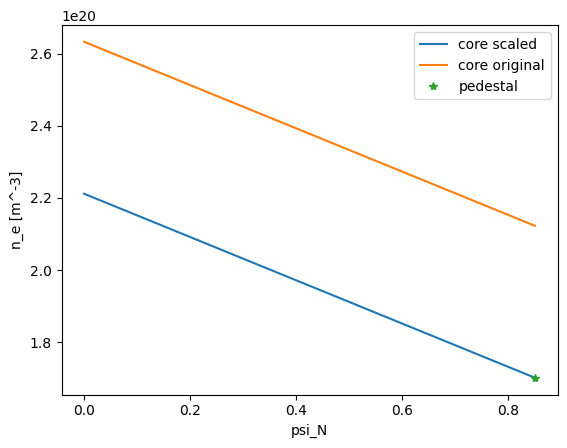

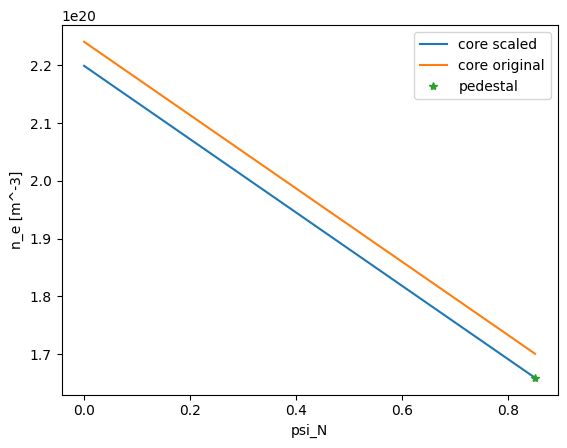

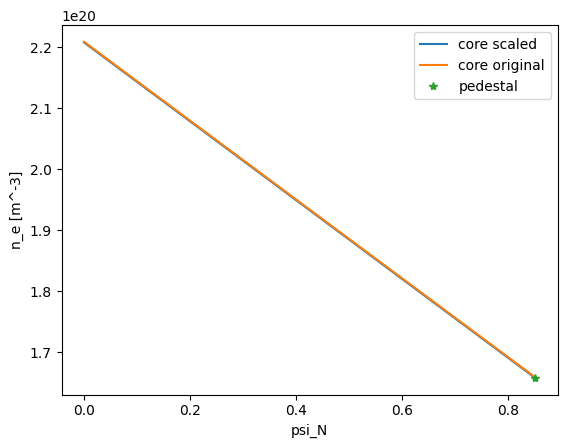

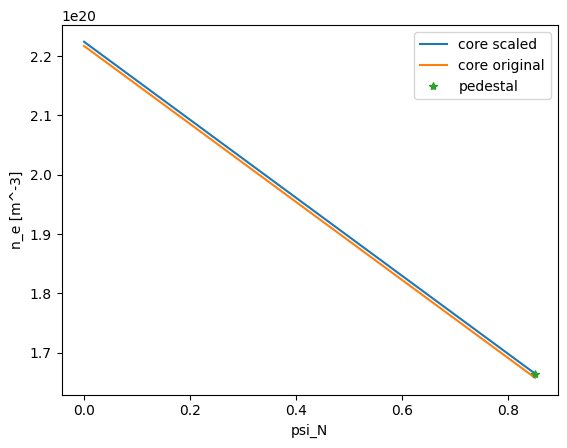

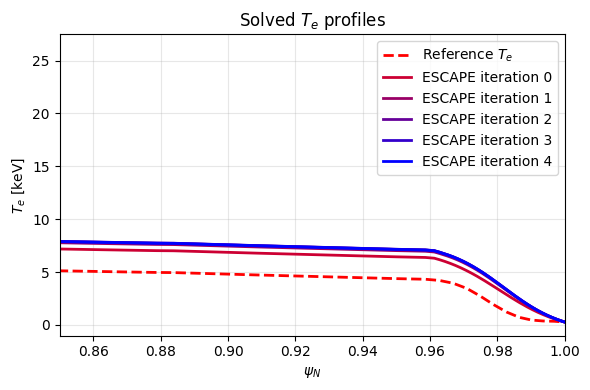

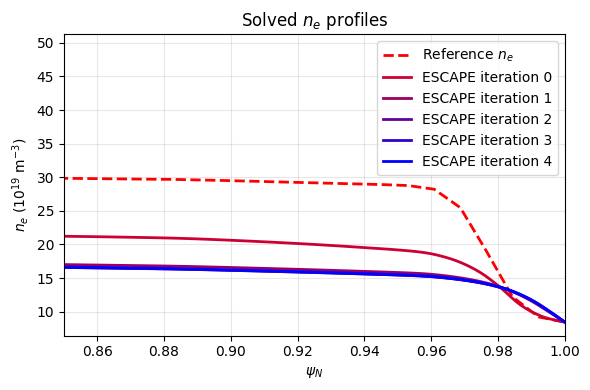

┌ Warning: Extrapolation warning on bt=12.492632729938999 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


In [6]:
# ESCAPE run
ped_wid, ped_h_out, sol = profiles_loop_solve(
    MHD_FP = mhd_fp,
    kprof_loc = 'manual psi_N grid',
    manual_profs = manual_profs,
    P_tot_e = P_tot_e,
    species = 'D-T',
    Z_eff = Zeff,
    out_dir = output_dir,
    x_res = x_res,
    free_params = free_params,
    eped_tol_max = eped_tol_max,
    eped_iter_max = eped_iter_max,
    kbm_gate_eps = kbm_gate_eps,
    kbm_treatment = kbm_treatment,
    picard_gate_mode = picard_gate_mode,
    picard_max_it = picard_max_it,
    picard_rtol = picard_rtol,
    picard_relax = picard_relax,
    ig = 'manual',
    epednn_model = epednn_model,
    EPEDNN_core = EPEDNN_core,
    verbose = verbose_EPEDNNloop,
    verbose_sc = verbose_sc,
)


In [ ]:
# Profile pressure at the EPEDNN-predicted pedestal top (psi_N = 1 - ped_wid)
psi_N_p, p_Pa, p_mode = calc_pressure_profile(profiles)
psi_ped_top = 1.0 - float(ped_wid)
p_at_ped_top = float(np.interp(psi_ped_top, psi_N_p, p_Pa))

print(f'Pressure formula: {p_mode}')
print(f'EPEDNN ped_top at psi_N = 1 - ped_wid = {psi_ped_top:.6f}')
print(f'Profile p(psi_ped_top) = {p_at_ped_top/1e3:.3f} kPa  ({p_at_ped_top/1e6:.4f} MPa)')
print(f'EPEDNN ped_h_out       = {float(ped_h_out)*1e3:.3f} kPa  ({float(ped_h_out):.4f} MPa)')
print(f'Accuracy of EPEDNN pedestal height prediction: {100*(float(p_at_ped_top/1e6) - float(ped_h_out))/float(ped_h_out):.2f}%')


In [ ]:
# Save model output
out_dict = {
    'mhd_fp': mhd_fp,
    'profiles': manual_profs,
    'ESCAPE_ped_h': ped_h_out,
    'ESCAPE_ped_wid': ped_wid,
    'experimental_ped_h': p_at_ped_top,
}
np.save(output_dir+'/SPARC_pedestal_prediction.npy', out_dict)